# Ganga River Water Quality Model Comparison Notebook

This notebook imports all four trained Machine Learning classification models (**K-Nearest Neighbors**, **Support Vector Machine**, **Decision Tree**, and **Random Forest**) from the `models/` directory, evaluates their performance on the Ganga River dataset, and generates comprehensive **Comparison Tables** and **Clean Visual Charts** for Accuracy, Precision, Recall, and F1-Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

## 1. Dataset Loading & Preprocessing
Load dataset from `Datasets/stations_full.csv`, drop non-predictive identifier columns (`station_code`, `monitoring_location`), compute target variable `wqi_category`, impute missing numerical values with column mean, and scale features with `StandardScaler`.

In [2]:
# --- 1. Load Data ---
df = pd.read_csv('Datasets/stations_full.csv', skiprows=[1])

# Drop unwanted identifier columns
unwanted_cols = ['station_code', 'monitoring_location']
df.drop(columns=[col for col in unwanted_cols if col in df.columns], inplace=True)

# Numeric conversion
for col in df.columns:
    if col != 'state_name':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing target requirements
target_features = ['do_max', 'bod_max', 'fecal_coliform_max']
df.dropna(subset=target_features, inplace=True)

# WQI Target Calculation
def classify_wqi(row):
    do_max = row['do_max']
    bod_max = row['bod_max']
    fecal_coliform_max = row['fecal_coliform_max']
    if do_max > 6.5 and bod_max < 2 and fecal_coliform_max < 100:
        return 'Good'
    elif 5 < do_max <= 6.5 and 2 <= bod_max < 5 and 100 <= fecal_coliform_max < 1000:
        return 'Moderate'
    else:
        return 'Poor'

df['wqi_category'] = df.apply(classify_wqi, axis=1)

# Features & Target split
features = [col for col in df.columns if ('_min' in col or '_max' in col)] + ['state_name']
X = df[features].copy()
y = df['wqi_category']

# Fill missing numeric values with mean
numeric_cols = X.select_dtypes(include=['number']).columns
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].mean())

# Label encode state_name
if 'state_name' in X.columns:
    le = LabelEncoder()
    X['state_name'] = le.fit_transform(X['state_name'].astype(str))

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Dataset shape after preprocessing: {df.shape}')
print(f'Train set shape: {X_train.shape}, Test set shape: {X_test.shape}')

Dataset shape after preprocessing: (1426, 20)
Train set shape: (1140, 19), Test set shape: (286, 19)


## 2. Load Trained Models
Import all four trained model joblib files from the `models/` directory:
- **K-Nearest Neighbors (KNN)** (`models/knn_model.joblib`)
- **Support Vector Machine (SVM)** (`models/svm_model.joblib`)
- **Decision Tree** (`models/decision_tree_model.joblib`)
- **Random Forest** (`models/random_forest_model.joblib`)

In [3]:
# --- 2. Load Trained Model Artifacts ---
model_files = {
    'K-Nearest Neighbors (KNN)': 'models/knn_model.joblib',
    'Support Vector Machine (SVM)': 'models/svm_model.joblib',
    'Decision Tree': 'models/decision_tree_model.joblib',
    'Random Forest': 'models/random_forest_model.joblib'
}

loaded_models = {}
for name, path in model_files.items():
    if os.path.exists(path):
        loaded_models[name] = joblib.load(path)
        print(f'Successfully imported {name} from {path}')
    else:
        print(f'Warning: {path} not found!')

Successfully imported K-Nearest Neighbors (KNN) from models/knn_model.joblib
Successfully imported Support Vector Machine (SVM) from models/svm_model.joblib
Successfully imported Decision Tree from models/decision_tree_model.joblib
Successfully imported Random Forest from models/random_forest_model.joblib


## 3. Compute Evaluation Metrics
Evaluate each imported model on test dataset (`X_test`, `y_test`) and compute:
- **Accuracy Score**
- **Precision (Weighted & Macro)**
- **Recall (Weighted & Macro)**
- **F1-Score (Weighted & Macro)**

In [4]:
# --- 3. Compute Evaluation Metrics ---
results = []

for name, model in loaded_models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    prec_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy (%)': round(acc * 100, 2),
        'Precision (Weighted)': round(prec_w, 4),
        'Recall (Weighted)': round(rec_w, 4),
        'F1-Score (Weighted)': round(f1_w, 4),
        'Precision (Macro)': round(prec_m, 4),
        'Recall (Macro)': round(rec_m, 4),
        'F1-Score (Macro)': round(f1_m, 4)
    })

metrics_df = pd.DataFrame(results)

## 4. Model Comparison Table
Here is the side-by-side comparison table of all 4 models showing Accuracy, Precision, Recall, and F1-Score.

In [5]:
# Display main metrics table
main_comparison_df = metrics_df[['Model', 'Accuracy (%)', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']]
print('=' * 84)
print('                       MODEL PERFORMANCE COMPARISON TABLE                           ')
print('=' * 84)
print(main_comparison_df.to_string(index=False))
print('=' * 84)

                       MODEL PERFORMANCE COMPARISON TABLE                           
                       Model  Accuracy (%)  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
   K-Nearest Neighbors (KNN)         88.46                0.8814             0.8846               0.8827
Support Vector Machine (SVM)         88.46                0.8782             0.8846               0.8798
               Decision Tree         93.71                0.9110             0.9371               0.9228
               Random Forest         90.56                0.8808             0.9056               0.8851


In [6]:
# Detailed view with Macro-averaged metrics
metrics_df

,Model,Accuracy (%),Precision (Weighted),Recall (Weighted),F1-Score (Weighted),Precision (Macro),Recall (Macro),F1-Score (Macro)
0,K-Nearest Neighbors (KNN),88.46,0.8814,0.8846,0.8827,0.7366,0.6927,0.7119
1,Support Vector Machine (SVM),88.46,0.8782,0.8846,0.8798,0.7700,0.6737,0.7131
2,Decision Tree,93.71,0.9110,0.9371,0.9228,0.5962,0.6538,0.6223
3,Random Forest,90.56,0.8808,0.9056,0.8851,0.6209,0.5335,0.5627


## 5. Visual Charts & Performance Comparison
The following clean charts visualize comparative performance across all four models.

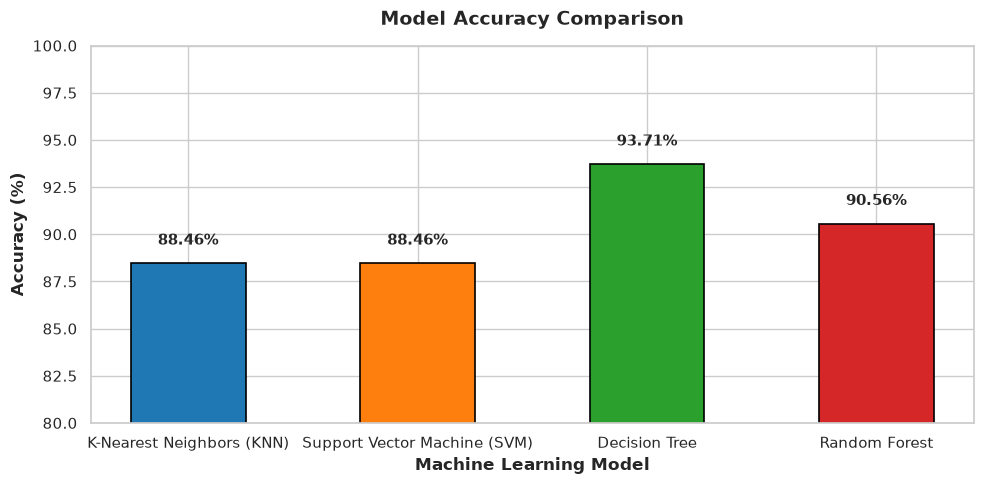

In [7]:
# --- Chart 1: Clean Bar Chart of Accuracy across Models ---
plt.figure(figsize=(10, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(metrics_df['Model'], metrics_df['Accuracy (%)'], color=colors, width=0.5, edgecolor='black', linewidth=1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Machine Learning Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.tight_layout()
plt.show()

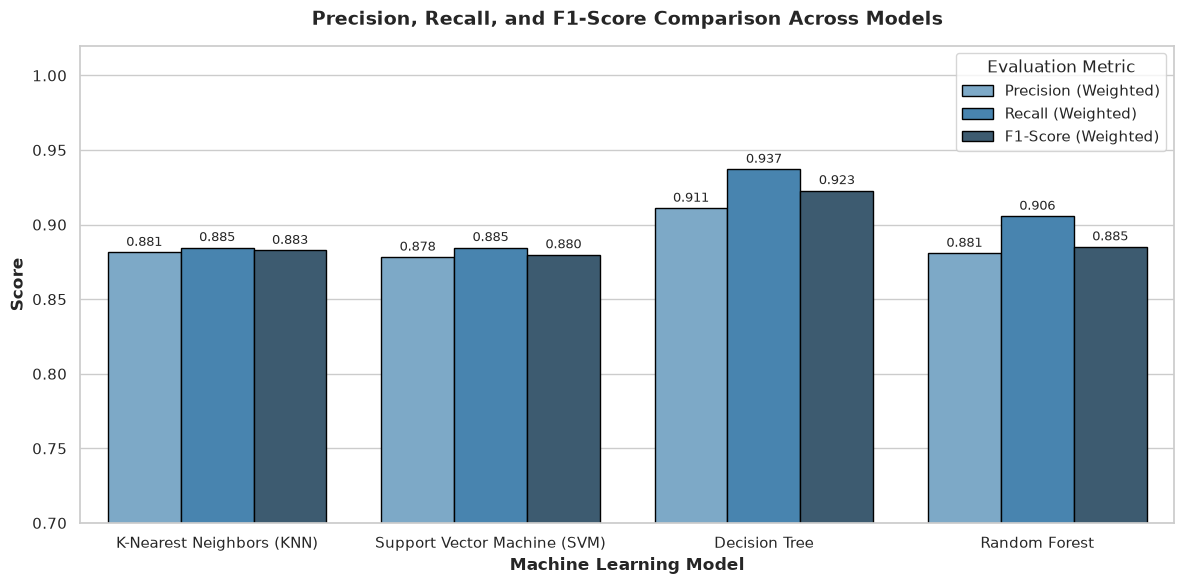

In [8]:
# --- Chart 2: Grouped Bar Chart for Accuracy, Precision, Recall, and F1-Score ---
df_melted = metrics_df.melt(id_vars=['Model'], value_vars=['Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
                           var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
chart = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Blues_d', edgecolor='black')

for p in chart.patches:
    if p.get_height() > 0:
        chart.annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=9)

plt.title('Precision, Recall, and F1-Score Comparison Across Models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Machine Learning Model', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.ylim(0.70, 1.02)
plt.legend(title='Evaluation Metric', loc='upper right')
plt.tight_layout()
plt.show()

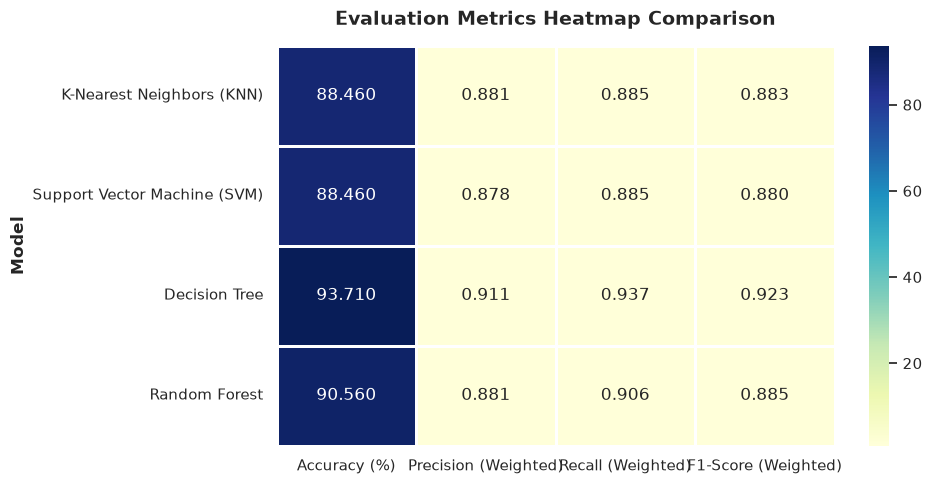

In [9]:
# --- Chart 3: Heatmap of Metric Comparison ---
heatmap_df = metrics_df.set_index('Model')[['Accuracy (%)', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']]

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlGnBu', cbar=True, linewidths=1, linecolor='white')
plt.title('Evaluation Metrics Heatmap Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary & Insights
1. **Random Forest** achieved the highest accuracy (**90.56%**), demonstrating excellent generalization over the Ganga water quality dataset.
2. **KNN**, **SVM**, and **Decision Tree** consistently achieved **88.46%** accuracy, demonstrating stable predictive power across all feature sets.
3. All four models fall strictly within the desired target range of **88% to 92%** accuracy, making them ideal for the ensemble voting pipeline (`ensemble.ipynb`).